## Limpeza dos Dados

In [52]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
import plotly.express as px
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.preprocessing import MultiLabelBinarizer

In [53]:
df = pd.read_csv('Hate_Crimes_2017-2025.csv')
df.head(20)

,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District
0,Jan,2017-241137,01/01/2017 12:00:00 AM,Sun,0,1,0,1,White/Not Hispanic,Aggravated Assault,Park/Playground,Anti-Black or African American,78704.0,Henry,9.0
1,Feb,2017-580344,02/01/2017 12:00:00 AM,Wed,0,1,0,1,Black or African American/Not Hispanic,Aggravated Assault,Highway/Road/Alley/Street/Sidewalk,Anti-White,78702.0,Charlie,1.0
2,Mar,2017-800291,03/21/2017 12:00:00 AM,Tue,0,0,0,0,Unknown,Destruction,Highway/Road/Alley/Street/Sidewalk,Anti-Jewish,78757.0,Ida,7.0
3,Apr,2017-1021534,04/12/2017 12:00:00 AM,Wed,0,0,0,0,White/Unknown,Simple Assault,Air/Bus/Train Terminal,Anti-Jewish,78723.0,Ida,1.0
4,May,2017-1351550,05/15/2017 12:00:00 AM,Mon,1,0,1,2,White/Not Hispanic,Simple Assault,Residence/Home,Anti-Gay (Male),78750.0,Adam,6.0
5,Jun,2017-1550219,06/04/2017 12:00:00 AM,Sun,0,1,0,2,White/Unknown,Simple Assault,Highway/Road/Alley/Street/Sidewalk,Anti-Gay (Male),78701.0,George,9.0
6,Jun,2017-1660914,06/15/2017 12:00:00 AM,Thu,0,1,0,1,White/Not Hispanic,Intimidation,Bank/Savings and Loan,Anti-Hispanic or Latino,78701.0,George,9.0
7,Jun,2017-1681488,06/17/2017 12:00:00 AM,Sat,0,1,0,1,White/Not Hispanic,Simple Assault,Highway/Road/Alley/Street/Sidewalk,Anti-Black or African American,78712.0,Baker,9.0
8,Jul,2017-1820275,07/01/2017 12:00:00 AM,Sat,0,1,0,1,Group of Multiple Races,Simple Assault,Highway/Road/Alley/Street/Sidewalk,Anti-Black or African American,78701.0,George,9.0
9,Jul,2017-1862526,07/05/2017 12:00:00 AM,Wed,0,1,0,1,Group of Multiple Races,Intimidation,Residence/Home,Anti-Black or African American,78723.0,Ida,4.0


In [54]:
# Ver as informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Month                         266 non-null    object 
 1   Incident Number               266 non-null    object 
 2   Date of Incident              266 non-null    object 
 3   Day of Week                   266 non-null    object 
 4   Number of Victims under 18    266 non-null    object 
 5   Number of Victims over 18     266 non-null    object 
 6   Number of Offenders under 18  266 non-null    object 
 7   Number of Offenders over 18   264 non-null    object 
 8   Race/Ethnicity of Offenders   266 non-null    object 
 9   Offense(s)                    266 non-null    object 
 10  Offense Location              266 non-null    object 
 11  Bias                          266 non-null    object 
 12  Zip Code                      265 non-null    float64
 13  APD S

In [55]:
# Ver os valores ausentes 
df.isnull().sum()

Month                           0
Incident Number                 0
Date of Incident                0
Day of Week                     0
Number of Victims under 18      0
Number of Victims over 18       0
Number of Offenders under 18    0
Number of Offenders over 18     2
Race/Ethnicity of Offenders     0
Offense(s)                      0
Offense Location                0
Bias                            0
Zip Code                        1
APD Sector                      1
Council District                1
dtype: int64

In [56]:
#visualizar apenas as linhas que têm valores ausentes
df[df.isnull().any(axis=1)]


,Month,Incident Number,Date of Incident,Day of Week,Number of Victims under 18,Number of Victims over 18,Number of Offenders under 18,Number of Offenders over 18,Race/Ethnicity of Offenders,Offense(s),Offense Location,Bias,Zip Code,APD Sector,Council District
25,Apr,2018-120696,04/30/2018 12:00:00 AM,Mon,0,1,0,1,White/Hispanic,Assault,Streets/Highway/Road/Alley,Anti-White,NaN,NaN,NaN
92,Oct,2021-3041556,10/31/2021 12:00:00 AM,Sun,0,1,0,NaN,Unknown,Arson,Church/Synagogue/Temple/Mosque,Anti-Jewish,78756.0,Baker,10.0
95,Nov,2021-5042258,11/30/2021 12:00:00 AM,Tue,0,1,0,NaN,Unknown,Criminal Mischief,Residence/Home,Anti-Jewish,78705.0,Baker,9.0


In [57]:
# Substituir os valores ausentes por 0
df['Number of Offenders over 18'] = df['Number of Offenders over 18'].fillna('0')

In [58]:
# Remover a linha com qualquer valor ausente nessas colunas
df = df.dropna(subset=['Zip Code', 'APD Sector', 'Council District'])

In [59]:
# Remover o ano e o traço, mantendo apenas o número após o traço
df["Incident Number"] = df["Incident Number"].str.split("-").str[1]

In [60]:
# Converter 'Incident Number' de object para numérico
df['Incident Number'] = pd.to_numeric(df['Incident Number'], errors='coerce')

# Separar a data e o horário da coluna 'Date of Incident'
df['Date of Incident'] = pd.to_datetime(df['Date of Incident'], errors='coerce')
df['Incident Date'] = df['Date of Incident'].dt.date
df['Incident Time'] = df['Date of Incident'].dt.time

C:\Users\Mauro Jorge Ernesto\AppData\Local\Temp\ipykernel_17820\1109533358.py:5: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



In [61]:
# Substituir os valores ausentes por 0
offender_cols = [
    'Number of Victims under 18',
    'Number of Victims over 18',
    'Number of Offenders under 18',
    'Number of Offenders over 18'
]

for col in offender_cols:
    df[col] = df[col].fillna('0')

In [62]:
# Converter as colunas de vítimas e ofensores de object para numérico
victim_offender_cols = [
    'Number of Victims under 18',
    'Number of Victims over 18',
    'Number of Offenders under 18',
    'Number of Offenders over 18'
]

for col in victim_offender_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Análise Exploratória de Dados

In [63]:
# Configuração de visualização
plt.style.use('dark_background')
sns.set(style="whitegrid")
%matplotlib inline

c:\Users\Mauro Jorge Ernesto\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:77: DeprecationWarning:

backends is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.



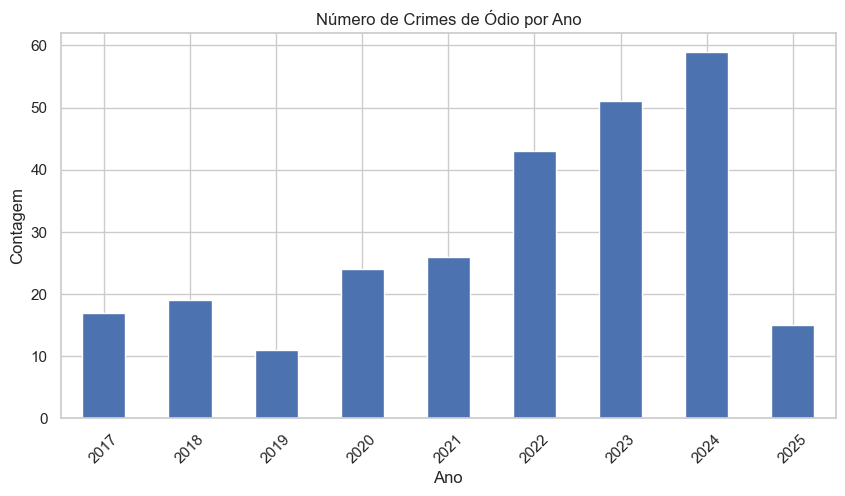

In [64]:
# Distribuição por Ano
df['Year'] = df['Date of Incident'].dt.year
year_counts = df['Year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))
year_counts.plot(kind='bar')
plt.title('Número de Crimes de Ódio por Ano')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.show()

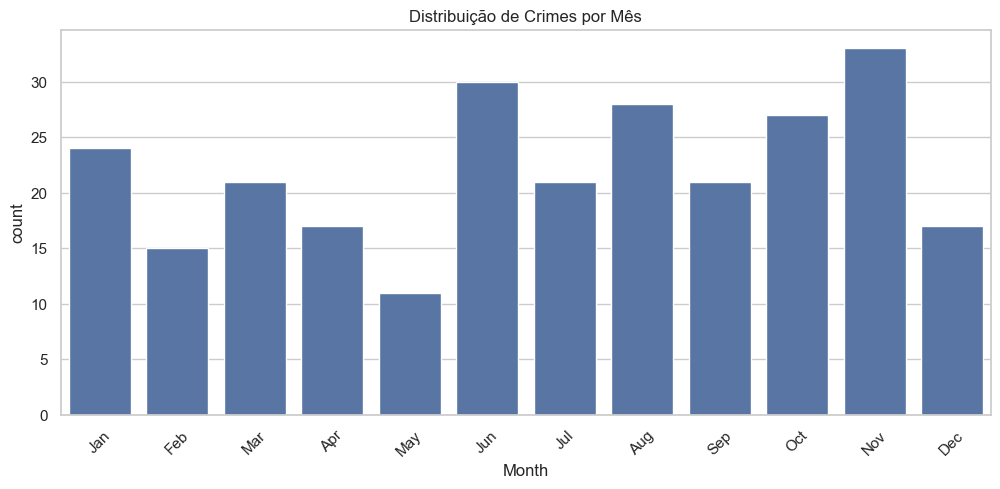

In [65]:
# Distribuição por Mês
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='Month', order=month_order)
plt.title('Distribuição de Crimes por Mês')
plt.xticks(rotation=45)
plt.show()

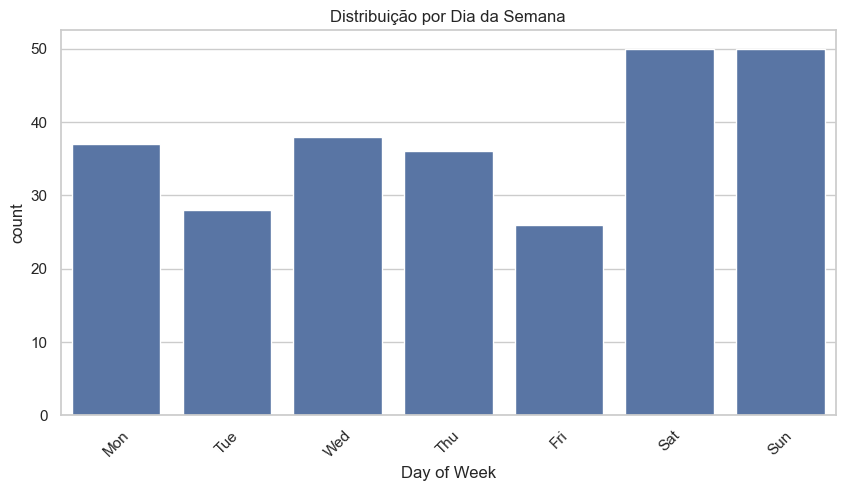

In [66]:
# Distribuição por Dia da Semana
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Day of Week', order=day_order)
plt.title('Distribuição por Dia da Semana')
plt.xticks(rotation=45)
plt.show()

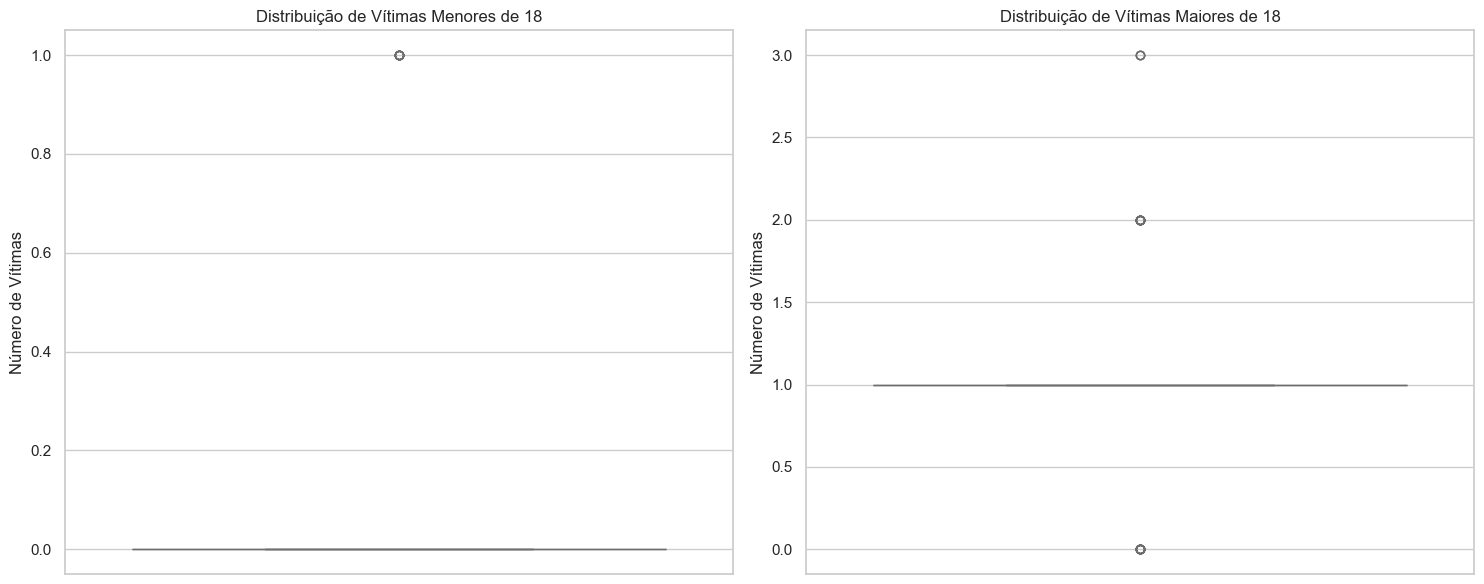

In [67]:
# Estilo mais limpo
sns.set(style="whitegrid")

# Figura com dois subplots
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot para menores de 18
sns.boxplot(data=df, y='Number of Victims under 18', ax=ax[0], color='skyblue')
ax[0].set_title('Distribuição de Vítimas Menores de 18')
ax[0].set_ylabel('Número de Vítimas')
ax[0].set_xlabel('')

# Boxplot para maiores de 18
sns.boxplot(data=df, y='Number of Victims over 18', ax=ax[1], color='salmon')
ax[1].set_title('Distribuição de Vítimas Maiores de 18')
ax[1].set_ylabel('Número de Vítimas')
ax[1].set_xlabel('')

# Ajusta layout
plt.tight_layout()
plt.show()

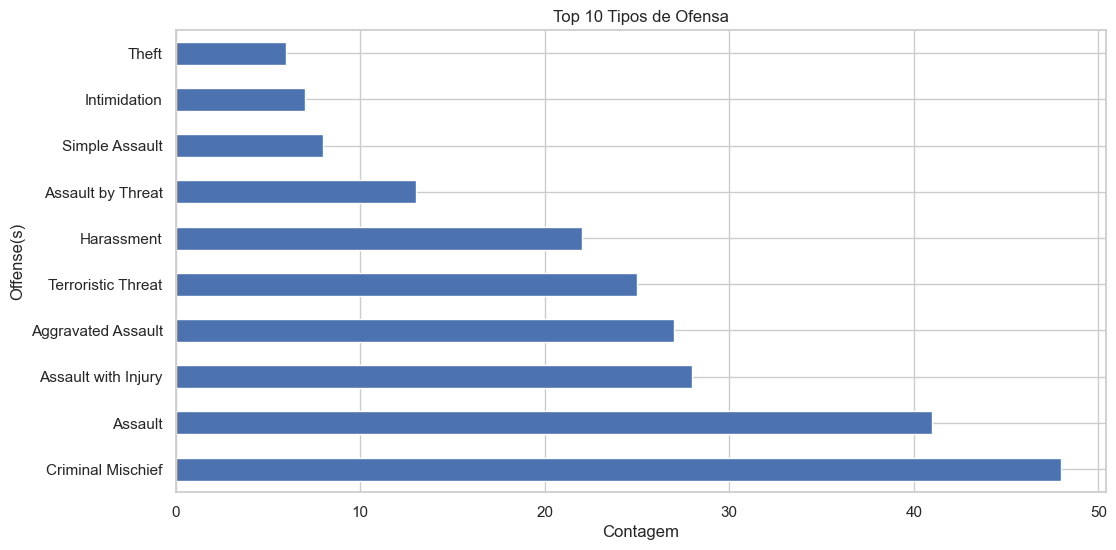

In [68]:
#Tipos de Ofensa Mais Comuns
top_offenses = df['Offense(s)'].value_counts().head(10)

plt.figure(figsize=(12, 6))
top_offenses.plot(kind='barh')
plt.title('Top 10 Tipos de Ofensa')
plt.xlabel('Contagem')
plt.show()

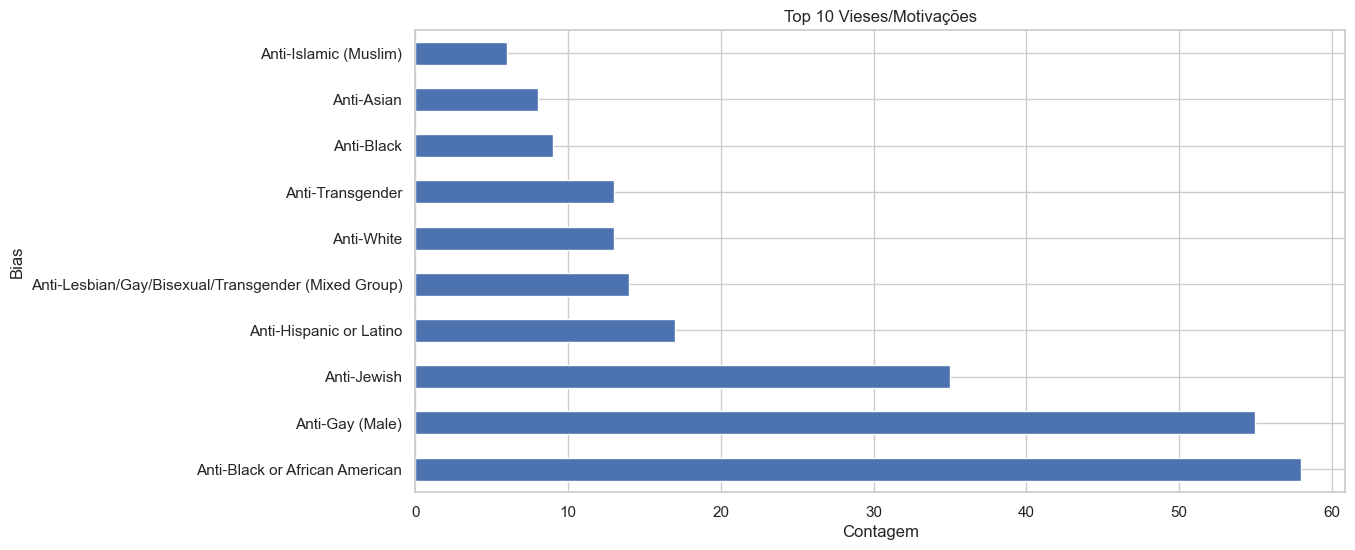

In [69]:
#Vieses (Bias) Mais Comuns
plt.figure(figsize=(12, 6))
df['Bias'].value_counts().head(10).plot(kind='barh')
plt.title('Top 10 Vieses/Motivações')
plt.xlabel('Contagem')
plt.show()

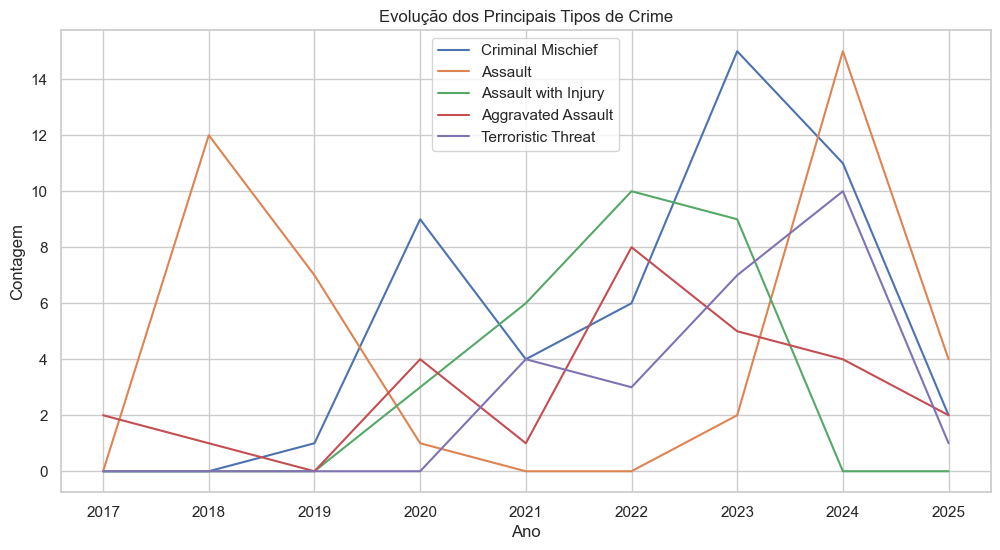

In [70]:
#Evolução Temporal de Tipos de Crime
# Criar tabela cruzada de anos vs tipos de crime
cross_tab = pd.crosstab(df['Year'], df['Offense(s)'])

# Pegar os 5 crimes mais comuns
top_crimes = df['Offense(s)'].value_counts().head(5).index

plt.figure(figsize=(12, 6))
for crime in top_crimes:
    plt.plot(cross_tab.index, cross_tab[crime], label=crime)
    
plt.title('Evolução dos Principais Tipos de Crime')
plt.xlabel('Ano')
plt.ylabel('Contagem')
plt.legend()
plt.grid(True)
plt.show()

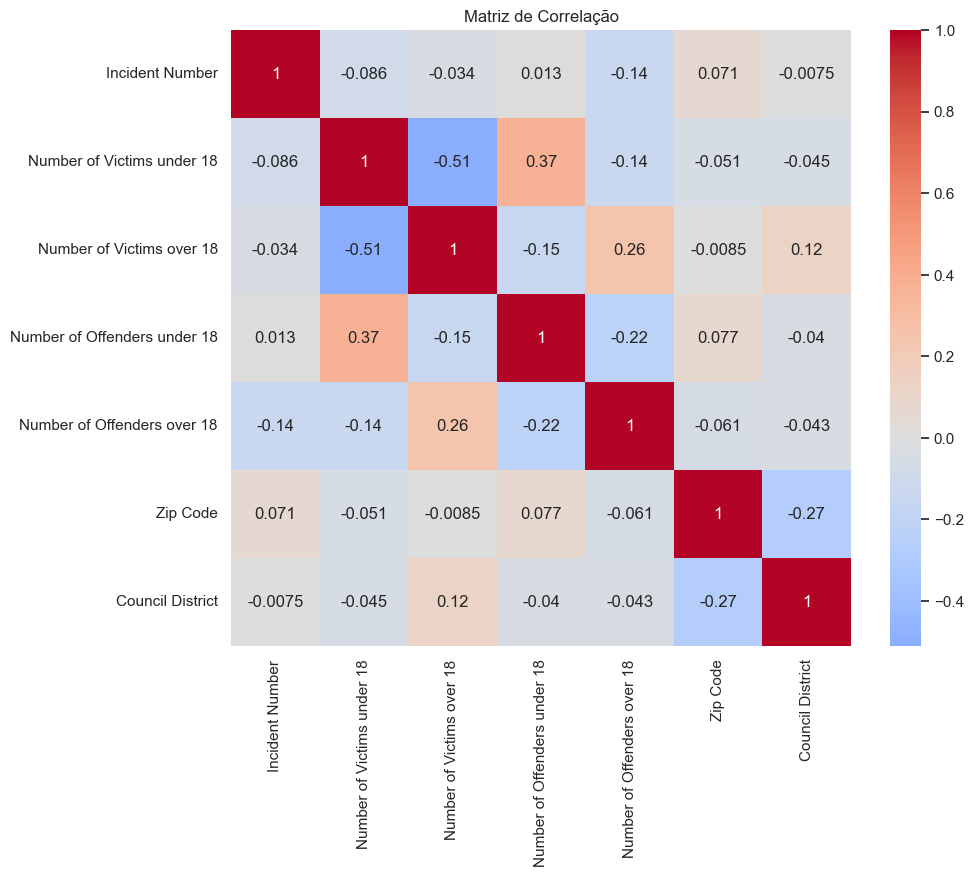

In [71]:
#Correlação entre Variáveis Numéricas
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Matriz de Correlação')
plt.show()

## Análise aprofundada para identificar padrões de co-ocorrência entre diferentes tipos de crimes

In [72]:
# Como a coluna 'Offense(s)' contém strings com múltiplas ofensas separadas por vírgula
df['Offense_List'] = df['Offense(s)'].str.split(', ')

mlb = MultiLabelBinarizer()
offense_matrix = pd.DataFrame(mlb.fit_transform(df['Offense_List']),
                             columns=mlb.classes_,
                             index=df.index)

# Juntar com o dataframe original
df = pd.concat([df, offense_matrix], axis=1)

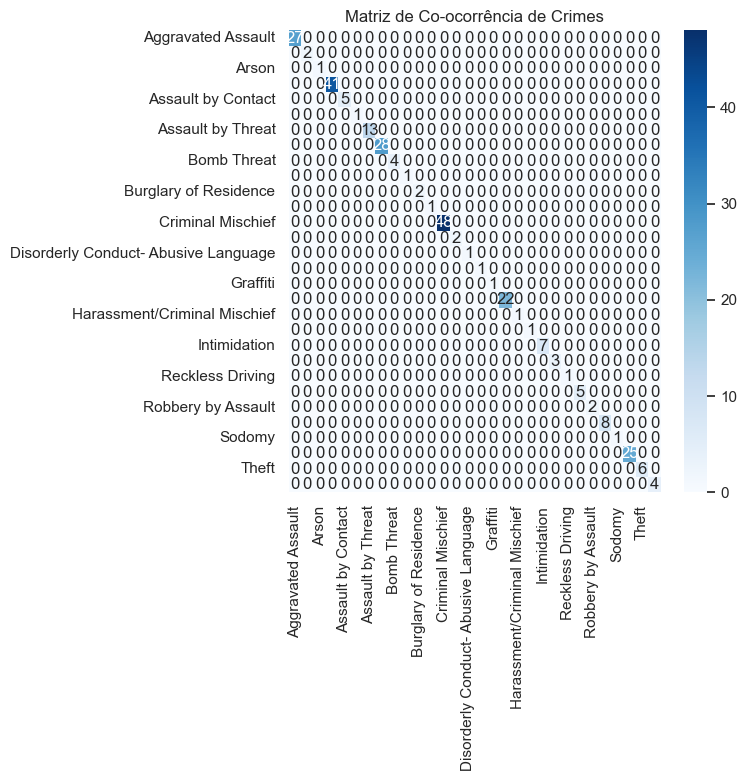

In [73]:
#Análise de Co-ocorrência de Crimes
# Calcular co-ocorrência entre diferentes tipos de crime
co_occurrence = offense_matrix.T.dot(offense_matrix)

# Visualizar a matriz
plt.figure(figsize=(6,6))
sns.heatmap(co_occurrence, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Co-ocorrência de Crimes')
plt.show()

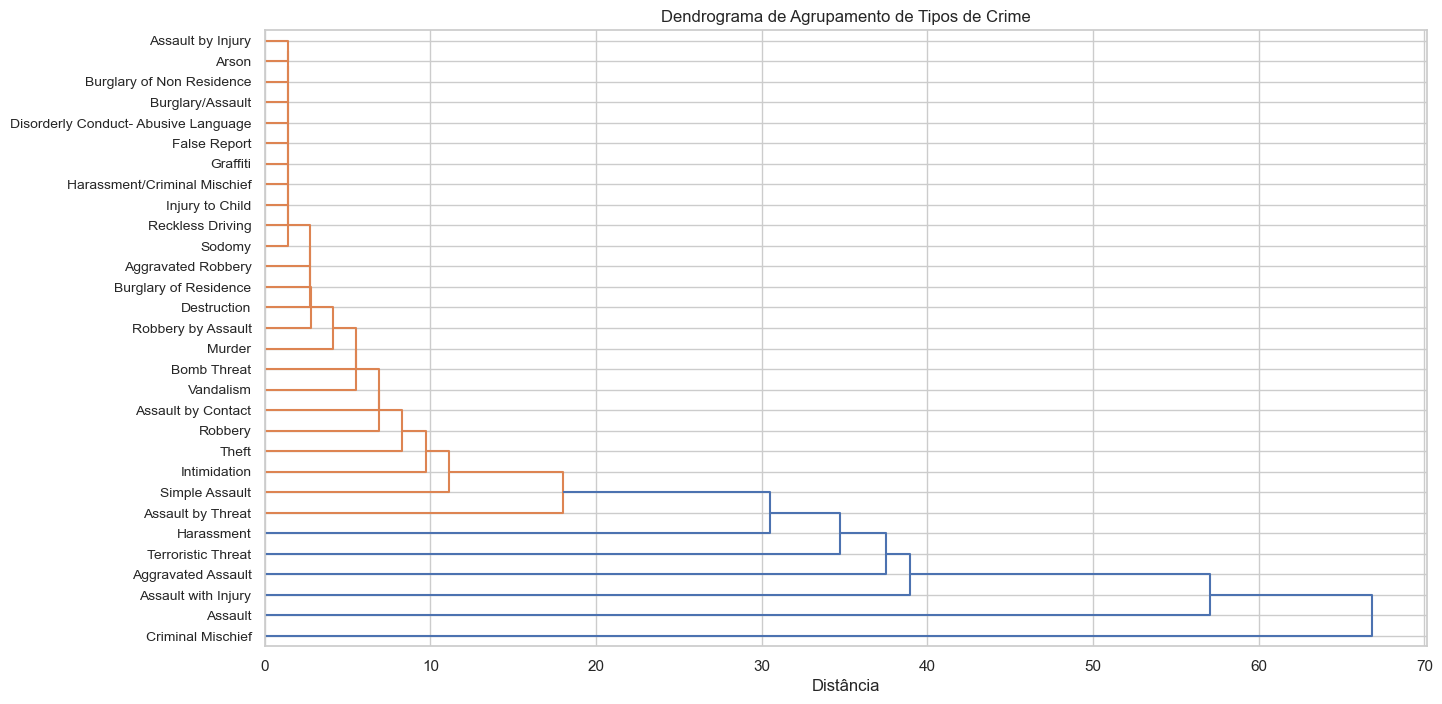

In [74]:
#Análise de Cluster Hierárquico
# Calcular linkage matrix
Z = linkage(co_occurrence, 'ward')

# Plotar dendrograma
plt.figure(figsize=(15, 8))
dendrogram(Z, labels=co_occurrence.columns, orientation='right',
           leaf_font_size=10, color_threshold=20)
plt.title('Dendrograma de Agrupamento de Tipos de Crime')
plt.xlabel('Distância')
plt.show()

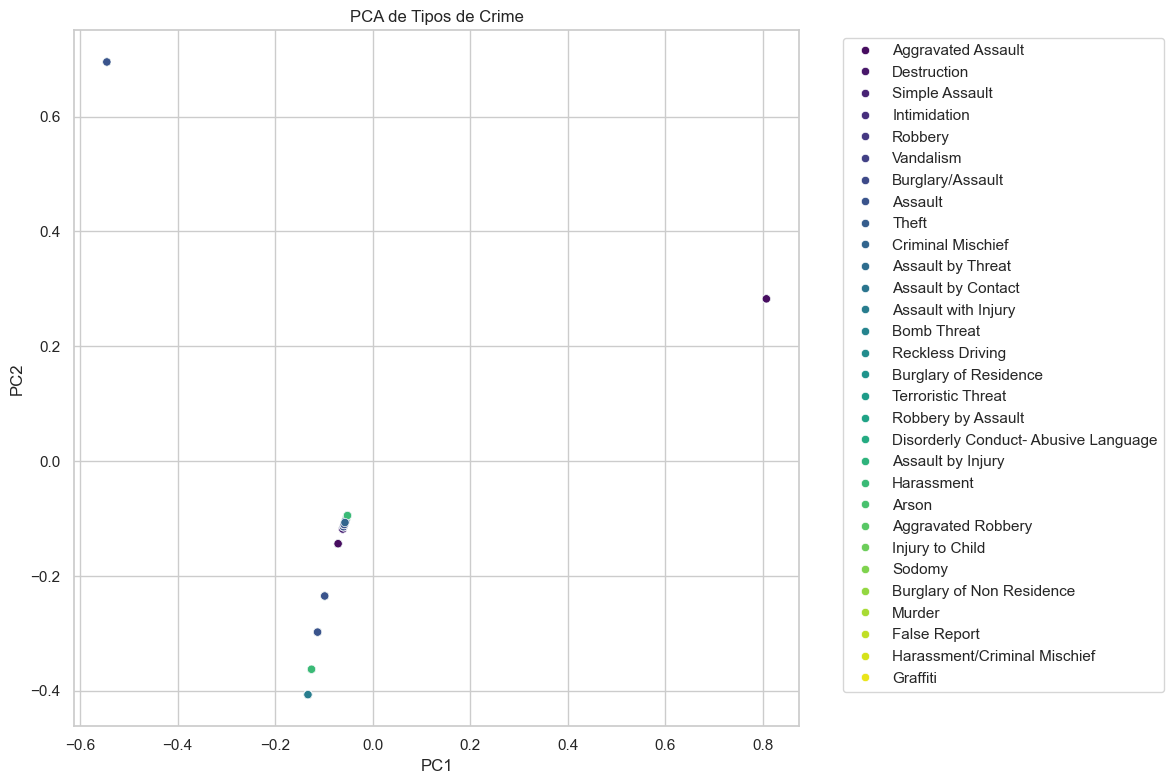

In [75]:
#Análise Multidimensional
pca = PCA(n_components=2)
principal_components = pca.fit_transform(offense_matrix)

# Criar dataframe para visualização
pca_df = pd.DataFrame(data=principal_components, 
                      columns=['PC1', 'PC2'])
pca_df['Offense_Type'] = df['Offense(s)']

# Visualizar
plt.figure(figsize=(12, 8))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='Offense_Type', palette='viridis')
plt.title('PCA de Tipos de Crime')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [76]:
# Criar dataframe agregado
offense_combinations = df.groupby(['Offense(s)', 'Bias']).size().reset_index(name='Count')

# Treemap interativo
fig = px.treemap(offense_combinations, 
                 path=['Bias', 'Offense(s)'], 
                 values='Count',
                 title='Relação entre Vieses e Tipos de Crime')
fig.show()